# 10. Baseline de regresion y experimentacion inicial

Este notebook implementa el primer bloque serio de experimentacion de modelos de regresion para el proyecto.

## Objetivos
- validar que el pipeline experimental definido en Semana 3 funciona de punta a punta
- comparar varias tecnicas de modelado sobre la base anual final
- experimentar con estrategias de seleccion de variables y conjuntos de features
- aplicar validacion temporal con ventanas crecientes
- generar tablas comparativas, metricas y un log final de resultados
- dejar un insumo claro para decidir que enfoques vale la pena profundizar en la siguiente fase


## Enfoque de este notebook

El trabajo de este notebook se organiza en seis capas:

- verificacion de dependencias y carga de datos
- definicion de conjuntos de variables y ventanas temporales
- prueba pequena del pipeline experimental
- comparacion amplia de modelos y tecnicas
- lectura critica para detectar modelos degenerados
- exportacion de tablas, predicciones y log de corrida

La base principal usada aqui es `dataset_modelado_anual_limpio.csv`, coherente con el diseno experimental ya aprobado. En esta version se prioriza un comparativo mas robusto: se excluye MARS, se corrige PyGAM, se agregan redes neuronales con `MLPRegressor` y se ajusta el ranking final para no privilegiar modelos que colapsan a predicciones casi constantes.


## Notas sobre dependencias

Para ejecutar todos los experimentos del notebook se recomienda contar como minimo con:

- scikit-learn
- numpy
- pandas

Y de forma opcional:

- xgboost
- lightgbm
- pygam
- matplotlib y seaborn para graficas

No se usa `MARS` en esta version, asi que no hace falta `pyearth`. Tampoco hace falta instalar librerias adicionales para las redes neuronales propuestas, porque se implementan con `MLPRegressor` de `scikit-learn`.

Si alguna dependencia opcional no esta disponible, el notebook seguira funcionando y simplemente omitira esas tecnicas.


In [19]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 240)
pd.set_option('display.max_colwidth', 180)

MATPLOTLIB_AVAILABLE = True
SEABORN_AVAILABLE = True
SKLEARN_AVAILABLE = True
XGBOOST_AVAILABLE = True
LIGHTGBM_AVAILABLE = True
PYGAM_AVAILABLE = True

try:
    import matplotlib.pyplot as plt
except Exception:
    MATPLOTLIB_AVAILABLE = False
    plt = None

try:
    import seaborn as sns
except Exception:
    SEABORN_AVAILABLE = False
    sns = None

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.cross_decomposition import PLSRegression
    from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
    from sklearn.linear_model import ElasticNet, HuberRegressor, Lasso, LassoCV, LinearRegression, Ridge
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.model_selection import ParameterGrid
    from sklearn.neural_network import MLPRegressor
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import SplineTransformer, StandardScaler
except Exception:
    SKLEARN_AVAILABLE = False

try:
    from xgboost import XGBRegressor
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    from pygam import LinearGAM, s
except Exception:
    PYGAM_AVAILABLE = False


def find_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / 'BASE_DE_DATOS').exists():
            return candidate
    raise FileNotFoundError('No se encontro una carpeta BASE_DE_DATOS en la ruta actual ni en sus padres.')


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)
BASE_DATOS = PROJECT_ROOT / 'BASE_DE_DATOS'
INPUT_PATH = BASE_DATOS / 'FINALES' / 'dataset_modelado_anual_limpio.csv'
OUTPUT_DIR = PROJECT_ROOT / 'MODELOS' / 'resultados_10_baseline_regresion'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEPENDENCY_WARNING = None

dependency_report = pd.DataFrame([
    {'dependencia': 'numpy', 'disponible': True},
    {'dependencia': 'pandas', 'disponible': True},
    {'dependencia': 'matplotlib', 'disponible': MATPLOTLIB_AVAILABLE},
    {'dependencia': 'seaborn', 'disponible': SEABORN_AVAILABLE},
    {'dependencia': 'scikit-learn', 'disponible': SKLEARN_AVAILABLE},
    {'dependencia': 'xgboost', 'disponible': XGBOOST_AVAILABLE},
    {'dependencia': 'lightgbm', 'disponible': LIGHTGBM_AVAILABLE},
    {'dependencia': 'pygam', 'disponible': PYGAM_AVAILABLE}
])


def dependency_status_text(df_report: pd.DataFrame) -> str:
    available = df_report.loc[df_report['disponible'], 'dependencia'].tolist()
    missing = df_report.loc[~df_report['disponible'], 'dependencia'].tolist()
    return f"Disponibles: {', '.join(available)} | Faltantes: {', '.join(missing) if missing else 'ninguna'}"


In [20]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f'No existe el archivo esperado: {INPUT_PATH}')

print('Rutas validadas correctamente.')
display(dependency_report)

if not SKLEARN_AVAILABLE:
    DEPENDENCY_WARNING = 'ATENCION: scikit-learn no esta disponible en este entorno. El notebook seguira mostrando la preparacion y la configuracion, pero no podra correr los modelos hasta instalar esa dependencia.'
    print(DEPENDENCY_WARNING)


Rutas validadas correctamente.


,dependencia,disponible
0,numpy,True
1,pandas,True
2,matplotlib,True
3,seaborn,True
4,scikit-learn,True
5,xgboost,True
6,lightgbm,True
7,pygam,True


## Carga de la base anual final

Se carga la base oficial de modelado definida en el notebook 09.


In [21]:
df = pd.read_csv(INPUT_PATH, sep=';').sort_values(['departamento', 'anio']).reset_index(drop=True)
df['es_risaralda'] = df['departamento'].eq('Risaralda').astype(int)

print('Shape base anual final:', df.shape)
display(df[['departamento', 'anio', 'perdida_rendimiento_anual_pct', 'evento_perdida_anual']].head(8))


Shape base anual final: (36, 81)


,departamento,anio,perdida_rendimiento_anual_pct,evento_perdida_anual
0,Cundinamarca,2007,-15.245048,1
1,Cundinamarca,2008,-11.479062,0
2,Cundinamarca,2009,-7.713077,0
3,Cundinamarca,2010,-9.120406,0
4,Cundinamarca,2011,-5.456866,0
5,Cundinamarca,2012,-10.482027,0
6,Cundinamarca,2013,-25.345584,1
7,Cundinamarca,2014,-19.247836,1


## Parametros del experimento

Se toman como referencia las decisiones metodologicas del notebook 09.


In [22]:
TARGET = 'perdida_rendimiento_anual_pct'
EVENT_THRESHOLD = -15.0
TRAIN_END_YEAR = 2020
SMALL_TRAIN_END_YEAR = 2018
SMALL_VALID_END_YEAR = 2020
CV_MIN_TRAIN_YEARS = 6
CV_VALID_WINDOW = 2
DEGENERATE_STD_THRESHOLD = 0.25
DEGENERATE_RANGE_THRESHOLD = 0.50
PRIMARY_PENALTY_DEGENERATE = 50.0
BUSINESS_RECALL_WEIGHT = 8.0
BUSINESS_F1_WEIGHT = 4.0
BUSINESS_PRECISION_REWARD = 1.0
MAX_ENSEMBLE_MODELS = 3

baseline_feature_set = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_annual_sum',
    'temp_aire_C_annual_mean',
    'def_annual_mean',
    'GDD_cafe_annual_mean',
    'NDVI_anomalia_pct_annual_mean',
    'precipitation_cosecha_sum',
    'temp_aire_C_cosecha_mean',
    'NDVI_anomalia_pct_cosecha_mean'
]

annual_core = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_annual_sum',
    'temp_aire_C_annual_mean',
    'def_annual_mean',
    'GDD_cafe_annual_mean',
    'NDVI_anomalia_pct_annual_mean'
]

harvest_core = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_cosecha_sum',
    'temp_aire_C_cosecha_mean',
    'def_cosecha_mean',
    'NDVI_anomalia_pct_cosecha_mean'
]

annual_plus_terrain = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_annual_sum',
    'temp_aire_C_annual_mean',
    'def_annual_mean',
    'GDD_cafe_annual_mean',
    'NDVI_anomalia_pct_annual_mean',
    'elevacion_media_m',
    'pendiente_media'
]

satellite_focus = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'NDVI_annual_mean',
    'EVI_annual_mean',
    'Gpp_annual_mean',
    'Lai_500m_annual_mean',
    'NDVI_anomalia_pct_cosecha_mean',
    'EVI_anomalia_pct_cosecha_mean',
    'Gpp_anomalia_pct_cosecha_mean'
]

exploratory_feature_pool = [
    'es_risaralda', 'n_municipios', 'precio_ico_usd_ton', 'precio_productor_usd_ton',
    'precipitation_annual_sum', 'temp_aire_C_annual_mean', 'humedad_relativa_pct_annual_mean',
    'soil_annual_mean', 'def_annual_mean', 'pet_annual_mean', 'aet_annual_mean',
    'GDD_cafe_annual_mean', 'NDVI_annual_mean', 'EVI_annual_mean', 'Gpp_annual_mean',
    'Lai_500m_annual_mean', 'Fpar_500m_annual_mean', 'NDVI_anomalia_pct_annual_mean',
    'EVI_anomalia_pct_annual_mean', 'Gpp_anomalia_pct_annual_mean',
    'precipitation_anomalia_pct_annual_mean', 'precipitation_cosecha_sum',
    'temp_aire_C_cosecha_mean', 'humedad_relativa_pct_cosecha_mean', 'soil_cosecha_mean',
    'def_cosecha_mean', 'pet_cosecha_mean', 'aet_cosecha_mean', 'GDD_cafe_cosecha_mean',
    'NDVI_cosecha_mean', 'EVI_cosecha_mean', 'Gpp_cosecha_mean', 'Lai_500m_cosecha_mean',
    'Fpar_500m_cosecha_mean', 'NDVI_anomalia_pct_cosecha_mean',
    'EVI_anomalia_pct_cosecha_mean', 'Gpp_anomalia_pct_cosecha_mean',
    'precipitation_anomalia_pct_cosecha_mean', 'elevacion_media_m', 'pendiente_media'
]

feature_config = pd.DataFrame([
    {'grupo': 'baseline_parsimonioso', 'n_variables': len(baseline_feature_set), 'variables': ', '.join(baseline_feature_set)},
    {'grupo': 'annual_core', 'n_variables': len(annual_core), 'variables': ', '.join(annual_core)},
    {'grupo': 'harvest_core', 'n_variables': len(harvest_core), 'variables': ', '.join(harvest_core)},
    {'grupo': 'annual_plus_terrain', 'n_variables': len(annual_plus_terrain), 'variables': ', '.join(annual_plus_terrain)},
    {'grupo': 'satellite_focus', 'n_variables': len(satellite_focus), 'variables': ', '.join(satellite_focus)},
    {'grupo': 'exploratory_feature_pool', 'n_variables': len(exploratory_feature_pool), 'variables': ', '.join(exploratory_feature_pool[:12]) + ' ...'}
])
display(feature_config)


,grupo,n_variables,variables
0,baseline_parsimonioso,10,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean, precipitation_cosecha..."
1,annual_core,7,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean"
2,harvest_core,6,"es_risaralda, precio_ico_usd_ton, precipitation_cosecha_sum, temp_aire_C_cosecha_mean, def_cosecha_mean, NDVI_anomalia_pct_cosecha_mean"
3,annual_plus_terrain,9,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean, elevacion_media_m, pe..."
4,satellite_focus,9,"es_risaralda, precio_ico_usd_ton, NDVI_annual_mean, EVI_annual_mean, Gpp_annual_mean, Lai_500m_annual_mean, NDVI_anomalia_pct_cosecha_mean, EVI_anomalia_pct_cosecha_mean, Gpp_a..."
5,exploratory_feature_pool,40,"es_risaralda, n_municipios, precio_ico_usd_ton, precio_productor_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, humedad_relativa_pct_annual_mean, soil_annual_mean,..."


## Helpers de evaluacion y splits temporales

Las funciones siguientes estructuran la validacion temporal, el calculo de metricas y las tablas de salida.


In [23]:
run_log = []


def log(message: str):
    print(message)
    run_log.append(message)


if DEPENDENCY_WARNING is not None:
    log(DEPENDENCY_WARNING)


def prediction_behavior_metrics(y_pred):
    y_pred = np.asarray(y_pred).astype(float)
    pred_std = float(np.std(y_pred)) if len(y_pred) > 0 else np.nan
    pred_range = float(np.max(y_pred) - np.min(y_pred)) if len(y_pred) > 0 else np.nan
    pred_unique = int(np.unique(np.round(y_pred, 8)).size) if len(y_pred) > 0 else 0
    degenerate_flag = bool((pred_unique <= 1) or (pred_std < DEGENERATE_STD_THRESHOLD) or (pred_range < DEGENERATE_RANGE_THRESHOLD))
    return {
        'pred_std': pred_std,
        'pred_range': pred_range,
        'pred_unique': pred_unique,
        'degenerate_prediction_flag': degenerate_flag
    }


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    if len(y_true) > 1 and np.std(y_true) > 0:
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot
    else:
        r2 = np.nan
    directional_accuracy = float(np.mean(np.sign(y_true) == np.sign(y_pred)))
    return {
        'mae': mae,
        'rmse': rmse,
        'r2': float(r2),
        'directional_accuracy': directional_accuracy,
        **prediction_behavior_metrics(y_pred)
    }


def event_metrics_from_regression(y_true, y_pred, threshold=-15.0):
    actual = np.asarray(y_true) <= threshold
    pred = np.asarray(y_pred) <= threshold
    tp = int(np.sum(actual & pred))
    fp = int(np.sum(~actual & pred))
    fn = int(np.sum(actual & ~pred))
    tn = int(np.sum(~actual & ~pred))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    return {
        'event_threshold': threshold,
        'event_accuracy': float(accuracy),
        'event_precision': float(precision),
        'event_recall': float(recall),
        'event_f1': float(f1),
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    }


def ranking_scores(metrics_dict, event_dict):
    primary_rank_score = float(metrics_dict['rmse'] + (PRIMARY_PENALTY_DEGENERATE if metrics_dict['degenerate_prediction_flag'] else 0.0))
    business_rank_score = float(
        metrics_dict['rmse']
        + (PRIMARY_PENALTY_DEGENERATE if metrics_dict['degenerate_prediction_flag'] else 0.0)
        + BUSINESS_RECALL_WEIGHT * (1.0 - event_dict['event_recall'])
        + BUSINESS_F1_WEIGHT * (1.0 - event_dict['event_f1'])
        - BUSINESS_PRECISION_REWARD * event_dict['event_precision']
    )
    return {
        'primary_rank_score': primary_rank_score,
        'business_rank_score': business_rank_score
    }


def make_expanding_year_folds(train_df, year_col='anio', min_train_years=6, valid_window=2):
    years = sorted(train_df[year_col].unique().tolist())
    folds = []
    for end_idx in range(min_train_years, len(years), valid_window):
        train_years = years[:end_idx]
        valid_years = years[end_idx:end_idx + valid_window]
        if not valid_years:
            continue
        train_idx = train_df.index[train_df[year_col].isin(train_years)].tolist()
        valid_idx = train_df.index[train_df[year_col].isin(valid_years)].tolist()
        folds.append({
            'train_years': train_years,
            'valid_years': valid_years,
            'train_idx': train_idx,
            'valid_idx': valid_idx,
            'label': f"train_{train_years[0]}_{train_years[-1]}__valid_{valid_years[0]}_{valid_years[-1]}"
        })
    return folds


def flatten_pred(pred):
    pred = np.asarray(pred)
    if pred.ndim > 1:
        pred = pred.reshape(-1)
    return pred.astype(float)


def safe_write_text(path: Path, content: str):
    try:
        path.write_text(content, encoding='utf-8')
        return True
    except Exception as exc:
        print(f'No fue posible escribir {path.name}: {exc}')
        return False


## Definicion de datasets experimentales

Se separa un subconjunto pequeno para comprobar que el pipeline reporte bien la informacion y luego un split principal para comparar modelos.


In [24]:
main_train = df.loc[df['anio'] <= TRAIN_END_YEAR].copy().reset_index(drop=True)
main_test = df.loc[df['anio'] > TRAIN_END_YEAR].copy().reset_index(drop=True)

small_train = df.loc[df['anio'] <= SMALL_TRAIN_END_YEAR].copy().reset_index(drop=True)
small_valid = df.loc[(df['anio'] > SMALL_TRAIN_END_YEAR) & (df['anio'] <= SMALL_VALID_END_YEAR)].copy().reset_index(drop=True)
small_test = df.loc[df['anio'] > SMALL_VALID_END_YEAR].copy().reset_index(drop=True)

cv_folds = make_expanding_year_folds(main_train, min_train_years=CV_MIN_TRAIN_YEARS, valid_window=CV_VALID_WINDOW)

split_summary = pd.DataFrame([
    {'dataset': 'main_train', 'filas': int(len(main_train)), 'anio_min': int(main_train['anio'].min()), 'anio_max': int(main_train['anio'].max())},
    {'dataset': 'main_test', 'filas': int(len(main_test)), 'anio_min': int(main_test['anio'].min()), 'anio_max': int(main_test['anio'].max())},
    {'dataset': 'small_train', 'filas': int(len(small_train)), 'anio_min': int(small_train['anio'].min()), 'anio_max': int(small_train['anio'].max())},
    {'dataset': 'small_valid', 'filas': int(len(small_valid)), 'anio_min': int(small_valid['anio'].min()), 'anio_max': int(small_valid['anio'].max())},
    {'dataset': 'small_test', 'filas': int(len(small_test)), 'anio_min': int(small_test['anio'].min()), 'anio_max': int(small_test['anio'].max())}
])

cv_summary = pd.DataFrame([
    {'fold': fold['label'], 'train_years': ','.join(map(str, fold['train_years'])), 'valid_years': ','.join(map(str, fold['valid_years'])), 'n_train': len(fold['train_idx']), 'n_valid': len(fold['valid_idx'])}
    for fold in cv_folds
])

display(split_summary)
display(cv_summary)
log(f'Se definieron {len(cv_folds)} folds de validacion temporal.')


,dataset,filas,anio_min,anio_max
0,main_train,28,2007,2020
1,main_test,8,2021,2024
2,small_train,24,2007,2018
3,small_valid,4,2019,2020
4,small_test,8,2021,2024


,fold,train_years,valid_years,n_train,n_valid
0,train_2007_2012__valid_2013_2014,"2007,2008,2009,2010,2011,2012","2013,2014",12,4
1,train_2007_2014__valid_2015_2016,"2007,2008,2009,2010,2011,2012,2013,2014","2015,2016",16,4
2,train_2007_2016__valid_2017_2018,"2007,2008,2009,2010,2011,2012,2013,2014,2015,2016","2017,2018",20,4
3,train_2007_2018__valid_2019_2020,"2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018","2019,2020",24,4


Se definieron 4 folds de validacion temporal.


## Construccion dinamica de estrategias de variables

Ademas de los conjuntos definidos manualmente, se construyen dos estrategias adicionales a partir del train principal:

- seleccion por correlacion absoluta con el target
- seleccion por correlacion con filtro de colinealidad

Opcionalmente, si scikit-learn esta disponible, tambien se intenta una seleccion basada en LassoCV.


In [25]:
dynamic_feature_sets = {}

corr_train = main_train[exploratory_feature_pool + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
corr_top8 = corr_train.head(8).index.tolist()
if 'es_risaralda' in exploratory_feature_pool and 'es_risaralda' not in corr_top8:
    corr_top8 = ['es_risaralda'] + corr_top8[:-1]
dynamic_feature_sets['corr_top8_train'] = corr_top8

selected_diverse = []
candidate_order = corr_train.index.tolist()
for feat in candidate_order:
    if not selected_diverse:
        selected_diverse.append(feat)
        continue
    corr_with_selected = main_train[selected_diverse + [feat]].corr(numeric_only=True)[feat].drop(feat).abs().max()
    if corr_with_selected < 0.85:
        selected_diverse.append(feat)
    if len(selected_diverse) >= 8:
        break
if 'es_risaralda' in exploratory_feature_pool and 'es_risaralda' not in selected_diverse:
    selected_diverse = ['es_risaralda'] + selected_diverse
selected_diverse = selected_diverse[:8]
dynamic_feature_sets['corr_diversified_train'] = selected_diverse

if SKLEARN_AVAILABLE:
    try:
        lasso_cv_splits = [(np.array(fold['train_idx']), np.array(fold['valid_idx'])) for fold in cv_folds]
        selector_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('lasso', LassoCV(alphas=np.logspace(-3, 1, 30), cv=lasso_cv_splits, max_iter=10000, random_state=42))
        ])
        selector_pipeline.fit(main_train[exploratory_feature_pool], main_train[TARGET])
        coefs = selector_pipeline.named_steps['lasso'].coef_
        lasso_selected = [feat for feat, coef in zip(exploratory_feature_pool, coefs) if abs(coef) > 1e-8]
        if len(lasso_selected) == 0:
            lasso_selected = dynamic_feature_sets['corr_top8_train']
        dynamic_feature_sets['lasso_selected_train'] = lasso_selected
    except Exception as exc:
        log(f'No fue posible construir lasso_selected_train: {exc}')

feature_sets = {
    'baseline_parsimonioso': baseline_feature_set,
    'annual_core': annual_core,
    'harvest_core': harvest_core,
    'annual_plus_terrain': annual_plus_terrain,
    'satellite_focus': satellite_focus,
    **dynamic_feature_sets
}

feature_sets_table = pd.DataFrame([
    {'feature_set': name, 'n_variables': len(features), 'variables': ', '.join(features)}
    for name, features in feature_sets.items()
])
display(feature_sets_table)


C:\Users\crist\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.102e+00, tolerance: 4.223e-01
  model = cd_fast.enet_coordinate_descent(
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.893e+00, tolerance: 4.223e-01
  model = cd_fast.enet_coordinate_descent(
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.578e-01, toleranc

,feature_set,n_variables,variables
0,baseline_parsimonioso,10,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean, precipitation_cosecha..."
1,annual_core,7,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean"
2,harvest_core,6,"es_risaralda, precio_ico_usd_ton, precipitation_cosecha_sum, temp_aire_C_cosecha_mean, def_cosecha_mean, NDVI_anomalia_pct_cosecha_mean"
3,annual_plus_terrain,9,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean, elevacion_media_m, pe..."
4,satellite_focus,9,"es_risaralda, precio_ico_usd_ton, NDVI_annual_mean, EVI_annual_mean, Gpp_annual_mean, Lai_500m_annual_mean, NDVI_anomalia_pct_cosecha_mean, EVI_anomalia_pct_cosecha_mean, Gpp_a..."
5,corr_top8_train,8,"es_risaralda, NDVI_cosecha_mean, NDVI_anomalia_pct_cosecha_mean, precio_productor_usd_ton, precio_ico_usd_ton, temp_aire_C_annual_mean, EVI_anomalia_pct_cosecha_mean, temp_aire..."
6,corr_diversified_train,8,"es_risaralda, NDVI_cosecha_mean, precio_productor_usd_ton, temp_aire_C_annual_mean, Fpar_500m_cosecha_mean, def_annual_mean, EVI_annual_mean, precipitation_cosecha_sum"
7,lasso_selected_train,8,"es_risaralda, NDVI_cosecha_mean, NDVI_anomalia_pct_cosecha_mean, precio_productor_usd_ton, precio_ico_usd_ton, temp_aire_C_annual_mean, EVI_anomalia_pct_cosecha_mean, temp_aire..."


## Smoke test del pipeline experimental

Antes de lanzar todas las combinaciones, se valida el proceso con un experimento pequeno sobre train_small y valid_small.


In [26]:
smoke_test_result = None

if SKLEARN_AVAILABLE:
    smoke_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    smoke_model.fit(small_train[baseline_feature_set], small_train[TARGET])
    smoke_pred = flatten_pred(smoke_model.predict(small_valid[baseline_feature_set]))
    smoke_metrics = regression_metrics(small_valid[TARGET], smoke_pred)
    smoke_events = event_metrics_from_regression(small_valid[TARGET], smoke_pred, threshold=EVENT_THRESHOLD)
    smoke_test_result = pd.DataFrame([{**smoke_metrics, **smoke_events}])
    display(smoke_test_result)
    display(pd.DataFrame({
        'departamento': small_valid['departamento'],
        'anio': small_valid['anio'],
        'y_real': small_valid[TARGET],
        'y_pred': smoke_pred
    }))
    log('Smoke test del pipeline completado correctamente con Regresion Lineal.')
else:
    log('Se omite el smoke test porque scikit-learn no esta disponible en este entorno.')


,mae,rmse,r2,directional_accuracy,pred_std,pred_range,pred_unique,degenerate_prediction_flag,event_threshold,event_accuracy,event_precision,event_recall,event_f1,tp,fp,fn,tn
0,26.655528,28.705044,-9.703794,0.75,21.850261,57.019602,4,False,-15.0,0.75,0.0,0.0,0.0,0,1,0,3


,departamento,anio,y_real,y_pred
0,Cundinamarca,2019,27.336301,-17.443112
1,Cundinamarca,2020,18.031732,0.589177
2,Risaralda,2019,16.746614,39.576490
3,Risaralda,2020,2.774230,24.344499


Smoke test del pipeline completado correctamente con Regresion Lineal.


## Registro de modelos a comparar

Se incluyen modelos lineales, regularizados, lineales robustos, reduccion de dimension, aproximaciones tipo GAM, arboles, boosting, redes neuronales y tecnicas opcionales si las dependencias estan presentes. En esta version no se incluye MARS.


In [27]:
model_specs = []

if SKLEARN_AVAILABLE:
    model_specs.extend([
        {
            'model_name': 'LinearRegression',
            'family': 'lineal',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': [{}]
        },
        {
            'model_name': 'HuberRegressor',
            'family': 'lineal_robusto',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'epsilon': [1.15, 1.35, 1.70], 'alpha': [0.0001, 0.001, 0.01]}))
        },
        {
            'model_name': 'Ridge',
            'family': 'regularizado',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'alpha': [0.01, 0.1, 1.0, 10.0, 50.0]}))
        },
        {
            'model_name': 'Lasso',
            'family': 'regularizado',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'alpha': [0.001, 0.01, 0.05, 0.1, 0.5]}))
        },
        {
            'model_name': 'ElasticNet',
            'family': 'regularizado',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'alpha': [0.001, 0.01, 0.1], 'l1_ratio': [0.2, 0.5, 0.8]}))
        },
        {
            'model_name': 'PLSRegression',
            'family': 'dimension_reducida',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'n_components': [1, 2, 3, 4]}))
        },
        {
            'model_name': 'SplineRidge_GAM_like',
            'family': 'gam_like',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'degree': [2, 3], 'n_knots': [3, 4, 5], 'alpha': [0.1, 1.0, 10.0]}))
        },
        {
            'model_name': 'RandomForest',
            'family': 'arboles',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'n_estimators': [300, 600], 'max_depth': [2, 3, None], 'min_samples_leaf': [1, 2, 4]}))
        },
        {
            'model_name': 'ExtraTrees',
            'family': 'arboles',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'n_estimators': [300, 600], 'max_depth': [2, 3, None], 'min_samples_leaf': [1, 2, 4]}))
        },
        {
            'model_name': 'GradientBoosting',
            'family': 'boosting',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'n_estimators': [100, 300], 'learning_rate': [0.03, 0.05, 0.1], 'max_depth': [2, 3]}))
        },
        {
            'model_name': 'HistGradientBoosting',
            'family': 'boosting',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'max_depth': [2, 3, None], 'learning_rate': [0.03, 0.05, 0.1], 'max_iter': [200, 500], 'min_samples_leaf': [1, 2, 4], 'l2_regularization': [0.0, 0.1, 1.0]}))
        },
        {
            'model_name': 'MLPRegressor_shallow',
            'family': 'red_neuronal',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'hidden_layer_sizes': [(8,), (16,), (32,)], 'alpha': [0.0005, 0.005], 'learning_rate_init': [0.001, 0.01]}))
        },
        {
            'model_name': 'MLPRegressor_deep',
            'family': 'red_neuronal',
            'allowed_feature_sets': list(feature_sets.keys()),
            'param_grid': list(ParameterGrid({'hidden_layer_sizes': [(16, 8), (32, 16)], 'alpha': [0.0005, 0.005], 'learning_rate_init': [0.001, 0.01]}))
        }
    ])

if XGBOOST_AVAILABLE:
    model_specs.append({
        'model_name': 'XGBoost',
        'family': 'boosting',
        'allowed_feature_sets': list(feature_sets.keys()),
        'param_grid': list(ParameterGrid({'n_estimators': [200, 400], 'max_depth': [2, 3], 'learning_rate': [0.03, 0.05], 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0], 'reg_lambda': [1.0, 5.0]}))
    })

if LIGHTGBM_AVAILABLE:
    model_specs.append({
        'model_name': 'LightGBM',
        'family': 'boosting',
        'allowed_feature_sets': list(feature_sets.keys()),
        'param_grid': list(ParameterGrid({'n_estimators': [200, 400], 'learning_rate': [0.03, 0.05], 'num_leaves': [7, 15, 31], 'min_child_samples': [1, 3, 5], 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0]}))
    })

if PYGAM_AVAILABLE:
    model_specs.append({
        'model_name': 'PyGAM',
        'family': 'gam',
        'allowed_feature_sets': list(feature_sets.keys()),
        'param_grid': list(ParameterGrid({'lam': [0.1, 1.0, 10.0]}))
    })

model_registry = pd.DataFrame([
    {'model_name': spec['model_name'], 'family': spec['family'], 'n_param_combinations': len(spec['param_grid']), 'n_feature_sets': len(spec['allowed_feature_sets'])}
    for spec in model_specs
])
if len(model_registry) > 0:
    display(model_registry)
    log(f'Se registraron {len(model_specs)} modelos para comparar.')
else:
    log('No se registra el zoo de modelos porque las dependencias de modelado no estan disponibles en este entorno.')


,model_name,family,n_param_combinations,n_feature_sets
0,LinearRegression,lineal,1,8
1,HuberRegressor,lineal_robusto,9,8
2,Ridge,regularizado,5,8
3,Lasso,regularizado,5,8
4,ElasticNet,regularizado,9,8
5,PLSRegression,dimension_reducida,4,8
6,SplineRidge_GAM_like,gam_like,18,8
7,RandomForest,arboles,18,8
8,ExtraTrees,arboles,18,8
9,GradientBoosting,boosting,12,8


Se registraron 16 modelos para comparar.


## Builders de modelos

Se encapsula la construccion de cada estimador para que el loop experimental pueda reutilizar el mismo protocolo de validacion y comparacion.


In [28]:
def build_model(model_name, features, params):
    if not SKLEARN_AVAILABLE:
        raise RuntimeError('scikit-learn no esta disponible.')

    if model_name == 'LinearRegression':
        return Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])

    if model_name == 'HuberRegressor':
        return Pipeline([('scaler', StandardScaler()), ('model', HuberRegressor(epsilon=params['epsilon'], alpha=params['alpha'], max_iter=500))])

    if model_name == 'Ridge':
        return Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=params['alpha']))])

    if model_name == 'Lasso':
        return Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=params['alpha'], max_iter=20000, random_state=42))])

    if model_name == 'ElasticNet':
        return Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=params['alpha'], l1_ratio=params['l1_ratio'], max_iter=20000, random_state=42))])

    if model_name == 'PLSRegression':
        n_components = min(params['n_components'], len(features))
        return Pipeline([('scaler', StandardScaler()), ('model', PLSRegression(n_components=n_components, scale=False))])

    if model_name == 'SplineRidge_GAM_like':
        spline_candidates = [
            'precipitation_annual_sum', 'temp_aire_C_annual_mean', 'def_annual_mean',
            'precipitation_cosecha_sum', 'temp_aire_C_cosecha_mean'
        ]
        spline_features = [f for f in spline_candidates if f in features][: min(4, len(features))]
        passthrough_features = [f for f in features if f not in spline_features]
        transformers = []
        if spline_features:
            transformers.append(('splines', SplineTransformer(n_knots=params['n_knots'], degree=params['degree'], include_bias=False), spline_features))
        if passthrough_features:
            transformers.append(('linear', 'passthrough', passthrough_features))
        preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
        return Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler(with_mean=False)), ('model', Ridge(alpha=params['alpha']))])

    if model_name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=1
        )

    if model_name == 'ExtraTrees':
        return ExtraTreesRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
            n_jobs=1
        )

    if model_name == 'GradientBoosting':
        return GradientBoostingRegressor(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            random_state=42
        )

    if model_name == 'HistGradientBoosting':
        return HistGradientBoostingRegressor(
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            max_iter=params['max_iter'],
            min_samples_leaf=params['min_samples_leaf'],
            l2_regularization=params['l2_regularization'],
            early_stopping=False,
            random_state=42
        )

    if model_name == 'MLPRegressor_shallow':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(
                hidden_layer_sizes=params['hidden_layer_sizes'],
                alpha=params['alpha'],
                learning_rate_init=params['learning_rate_init'],
                solver='lbfgs',
                max_iter=4000,
                random_state=42
            ))
        ])

    if model_name == 'MLPRegressor_deep':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(
                hidden_layer_sizes=params['hidden_layer_sizes'],
                alpha=params['alpha'],
                learning_rate_init=params['learning_rate_init'],
                solver='lbfgs',
                max_iter=5000,
                random_state=42
            ))
        ])

    if model_name == 'XGBoost' and XGBOOST_AVAILABLE:
        return XGBRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_lambda=params['reg_lambda'],
            objective='reg:squarederror',
            random_state=42,
            n_jobs=1,
            verbosity=0
        )

    if model_name == 'LightGBM' and LIGHTGBM_AVAILABLE:
        return LGBMRegressor(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            num_leaves=params['num_leaves'],
            min_child_samples=params['min_child_samples'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            random_state=42,
            verbose=-1,
            n_jobs=1
        )

    if model_name == 'PyGAM' and PYGAM_AVAILABLE:
        terms = s(0)
        for i in range(1, len(features)):
            terms = terms + s(i)
        return LinearGAM(terms, lam=params['lam'], fit_intercept=True, max_iter=500)

    raise ValueError(f'Modelo no soportado o no disponible: {model_name}')


## Loop principal de experimentacion

Se comparan combinaciones de modelos y conjuntos de variables usando validacion temporal con ventanas crecientes sobre el train principal. La seleccion de hiperparametros se hace con base en el RMSE promedio de validacion.


In [29]:
cv_results = []
test_results = []
prediction_rows = []
best_models_cache = {}

if SKLEARN_AVAILABLE:
    for spec in model_specs:
        model_name = spec['model_name']
        for feature_set_name in spec['allowed_feature_sets']:
            features = feature_sets[feature_set_name]
            best_score = np.inf
            best_payload = None

            for params in spec['param_grid']:
                fold_metrics = []
                fold_success = True
                for fold in cv_folds:
                    tr = main_train.loc[fold['train_idx']].copy()
                    va = main_train.loc[fold['valid_idx']].copy()
                    try:
                        model = build_model(model_name, features, params)
                        model.fit(tr[features], tr[TARGET])
                        pred_va = flatten_pred(model.predict(va[features]))
                        metrics = regression_metrics(va[TARGET], pred_va)
                        event_fold = event_metrics_from_regression(va[TARGET], pred_va, threshold=EVENT_THRESHOLD)
                        scores_fold = ranking_scores(metrics, event_fold)
                        fold_metrics.append({**metrics, **event_fold, **scores_fold})
                    except Exception as exc:
                        fold_success = False
                        log(f'Fallo {model_name} con {feature_set_name} y params {params}: {exc}')
                        break

                if not fold_success or len(fold_metrics) == 0:
                    continue

                avg_metrics = {
                    'cv_mae_mean': float(np.mean([m['mae'] for m in fold_metrics])),
                    'cv_rmse_mean': float(np.mean([m['rmse'] for m in fold_metrics])),
                    'cv_r2_mean': float(np.mean([m['r2'] for m in fold_metrics])),
                    'cv_directional_accuracy_mean': float(np.mean([m['directional_accuracy'] for m in fold_metrics])),
                    'cv_event_recall_mean': float(np.mean([m['event_recall'] for m in fold_metrics])),
                    'cv_event_f1_mean': float(np.mean([m['event_f1'] for m in fold_metrics])),
                    'cv_pred_std_mean': float(np.mean([m['pred_std'] for m in fold_metrics])),
                    'cv_degenerate_fold_share': float(np.mean([float(m['degenerate_prediction_flag']) for m in fold_metrics])),
                    'cv_selection_score_mean': float(np.mean([m['primary_rank_score'] for m in fold_metrics]))
                }

                cv_results.append({
                    'model_name': model_name,
                    'family': spec['family'],
                    'feature_set': feature_set_name,
                    'n_features': len(features),
                    'params': json.dumps(params, ensure_ascii=False),
                    **avg_metrics,
                    'n_folds': len(fold_metrics)
                })

                if avg_metrics['cv_selection_score_mean'] < best_score:
                    best_score = avg_metrics['cv_selection_score_mean']
                    best_payload = {
                        'params': params,
                        **avg_metrics
                    }

            if best_payload is None:
                continue

            final_model = build_model(model_name, features, best_payload['params'])
            final_model.fit(main_train[features], main_train[TARGET])
            pred_test = flatten_pred(final_model.predict(main_test[features]))
            metrics_test = regression_metrics(main_test[TARGET], pred_test)
            event_metrics = event_metrics_from_regression(main_test[TARGET], pred_test, threshold=EVENT_THRESHOLD)
            score_metrics = ranking_scores(metrics_test, event_metrics)

            test_results.append({
                'model_name': model_name,
                'family': spec['family'],
                'feature_set': feature_set_name,
                'n_features': len(features),
                'best_params': json.dumps(best_payload['params'], ensure_ascii=False),
                'cv_mae_mean': best_payload['cv_mae_mean'],
                'cv_rmse_mean': best_payload['cv_rmse_mean'],
                'cv_r2_mean': best_payload['cv_r2_mean'],
                'cv_event_recall_mean': best_payload['cv_event_recall_mean'],
                'cv_event_f1_mean': best_payload['cv_event_f1_mean'],
                'cv_pred_std_mean': best_payload['cv_pred_std_mean'],
                'cv_degenerate_fold_share': best_payload['cv_degenerate_fold_share'],
                'cv_selection_score_mean': best_payload['cv_selection_score_mean'],
                'test_mae': metrics_test['mae'],
                'test_rmse': metrics_test['rmse'],
                'test_r2': metrics_test['r2'],
                'test_directional_accuracy': metrics_test['directional_accuracy'],
                'test_pred_std': metrics_test['pred_std'],
                'test_pred_range': metrics_test['pred_range'],
                'test_pred_unique': metrics_test['pred_unique'],
                'degenerate_prediction_flag': metrics_test['degenerate_prediction_flag'],
                'event_precision': event_metrics['event_precision'],
                'event_recall': event_metrics['event_recall'],
                'event_f1': event_metrics['event_f1'],
                'event_accuracy': event_metrics['event_accuracy'],
                'tp': event_metrics['tp'],
                'fp': event_metrics['fp'],
                'fn': event_metrics['fn'],
                'tn': event_metrics['tn'],
                'primary_rank_score': score_metrics['primary_rank_score'],
                'business_rank_score': score_metrics['business_rank_score']
            })

            for dept, year, y_real, y_pred in zip(main_test['departamento'], main_test['anio'], main_test[TARGET], pred_test):
                prediction_rows.append({
                    'model_name': model_name,
                    'feature_set': feature_set_name,
                    'departamento': dept,
                    'anio': int(year),
                    'y_real': float(y_real),
                    'y_pred': float(y_pred),
                    'error': float(y_pred - y_real)
                })

            best_models_cache[(model_name, feature_set_name)] = {
                'model': final_model,
                'features': features,
                'spec': spec,
                'best_params': best_payload['params']
            }
            log(f"Completado {model_name} con feature_set={feature_set_name}. CV_SCORE={best_payload['cv_selection_score_mean']:.4f} | TEST_RMSE={metrics_test['rmse']:.4f} | DEG={int(metrics_test['degenerate_prediction_flag'])}")
else:
    log('Se omite el loop principal porque scikit-learn no esta disponible en este entorno.')


Completado LinearRegression con feature_set=baseline_parsimonioso. CV_SCORE=37.9050 | TEST_RMSE=18.0918 | DEG=0
Completado LinearRegression con feature_set=annual_core. CV_SCORE=19.1384 | TEST_RMSE=15.2481 | DEG=0
Completado LinearRegression con feature_set=harvest_core. CV_SCORE=20.6672 | TEST_RMSE=21.1018 | DEG=0
Completado LinearRegression con feature_set=annual_plus_terrain. CV_SCORE=19.1384 | TEST_RMSE=15.2481 | DEG=0
Completado LinearRegression con feature_set=satellite_focus. CV_SCORE=22.3196 | TEST_RMSE=31.9358 | DEG=0
Completado LinearRegression con feature_set=corr_top8_train. CV_SCORE=18.7635 | TEST_RMSE=26.4890 | DEG=0
Completado LinearRegression con feature_set=corr_diversified_train. CV_SCORE=18.5140 | TEST_RMSE=17.9268 | DEG=0
Completado LinearRegression con feature_set=lasso_selected_train. CV_SCORE=18.7635 | TEST_RMSE=26.4890 | DEG=0
Completado HuberRegressor con feature_set=baseline_parsimonioso. CV_SCORE=19.7118 | TEST_RMSE=18.2652 | DEG=0
Completado HuberRegressor c

C:\Users\crist\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.152e+01, tolerance: 3.308e-01
  model = cd_fast.enet_coordinate_descent(


Completado Lasso con feature_set=annual_core. CV_SCORE=17.7831 | TEST_RMSE=14.5554 | DEG=0
Completado Lasso con feature_set=harvest_core. CV_SCORE=16.2947 | TEST_RMSE=23.8565 | DEG=0
Completado Lasso con feature_set=annual_plus_terrain. CV_SCORE=17.7831 | TEST_RMSE=14.5554 | DEG=0
Completado Lasso con feature_set=satellite_focus. CV_SCORE=15.5031 | TEST_RMSE=25.7591 | DEG=0
Completado Lasso con feature_set=corr_top8_train. CV_SCORE=15.4257 | TEST_RMSE=25.0415 | DEG=0
Completado Lasso con feature_set=corr_diversified_train. CV_SCORE=15.7016 | TEST_RMSE=19.9324 | DEG=0
Completado Lasso con feature_set=lasso_selected_train. CV_SCORE=15.4257 | TEST_RMSE=25.0415 | DEG=0
Completado ElasticNet con feature_set=baseline_parsimonioso. CV_SCORE=14.6393 | TEST_RMSE=18.0933 | DEG=0
Completado ElasticNet con feature_set=annual_core. CV_SCORE=17.3481 | TEST_RMSE=14.3177 | DEG=0
Completado ElasticNet con feature_set=harvest_core. CV_SCORE=16.8956 | TEST_RMSE=23.1726 | DEG=0
Completado ElasticNet con f

C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Completado MLPRegressor_shallow con feature_set=baseline_parsimonioso. CV_SCORE=17.0877 | TEST_RMSE=19.7378 | DEG=0
Completado MLPRegressor_shallow con feature_set=annual_core. CV_SCORE=24.2734 | TEST_RMSE=68.6395 | DEG=0
Completado MLPRegressor_shallow con feature_set=harvest_core. CV_SCORE=18.0461 | TEST_RMSE=29.8432 | DEG=0


C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\crist\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Completado MLPRegressor_shallow con feature_set=annual_plus_terrain. CV_SCORE=25.0900 | TEST_RMSE=15.3318 | DEG=0
Completado MLPRegressor_shallow con feature_set=satellite_focus. CV_SCORE=20.4137 | TEST_RMSE=38.9335 | DEG=0
Completado MLPRegressor_shallow con feature_set=corr_top8_train. CV_SCORE=11.8038 | TEST_RMSE=17.7575 | DEG=0
Completado MLPRegressor_shallow con feature_set=corr_diversified_train. CV_SCORE=17.6903 | TEST_RMSE=27.7014 | DEG=0
Completado MLPRegressor_shallow con feature_set=lasso_selected_train. CV_SCORE=11.8038 | TEST_RMSE=17.7575 | DEG=0
Completado MLPRegressor_deep con feature_set=baseline_parsimonioso. CV_SCORE=15.2929 | TEST_RMSE=28.9332 | DEG=0
Completado MLPRegressor_deep con feature_set=annual_core. CV_SCORE=23.2975 | TEST_RMSE=25.7064 | DEG=0
Completado MLPRegressor_deep con feature_set=harvest_core. CV_SCORE=17.6278 | TEST_RMSE=26.4880 | DEG=0
Completado MLPRegressor_deep con feature_set=annual_plus_terrain. CV_SCORE=24.0665 | TEST_RMSE=20.9105 | DEG=0
Com

## Ensamble por union de modelos

Como experimento adicional, se construye un Voting Regressor a partir de los tres mejores modelos individuales dentro del feature set baseline parsimonioso, siempre que exista suficiente disponibilidad de modelos comparables.


In [30]:
if SKLEARN_AVAILABLE and len(test_results) > 0:
    test_results_df_tmp = pd.DataFrame(test_results)
    baseline_family_candidates = test_results_df_tmp.loc[
        (test_results_df_tmp['feature_set'] == 'baseline_parsimonioso') &
        (~test_results_df_tmp['degenerate_prediction_flag'])
    ].sort_values(['primary_rank_score', 'test_rmse'])

    if len(baseline_family_candidates) < MAX_ENSEMBLE_MODELS:
        baseline_family_candidates = test_results_df_tmp.loc[test_results_df_tmp['feature_set'] == 'baseline_parsimonioso'].sort_values(['primary_rank_score', 'test_rmse'])

    top_candidates = baseline_family_candidates.head(MAX_ENSEMBLE_MODELS)

    if len(top_candidates) >= MAX_ENSEMBLE_MODELS:
        estimators = []
        for _, row in top_candidates.iterrows():
            model_obj = best_models_cache[(row['model_name'], row['feature_set'])]['model']
            estimators.append((f"{row['model_name']}_{row['feature_set']}", model_obj))

        try:
            ensemble_model = VotingRegressor(estimators=estimators)
            ensemble_features = baseline_feature_set
            ensemble_model.fit(main_train[ensemble_features], main_train[TARGET])
            ensemble_pred = flatten_pred(ensemble_model.predict(main_test[ensemble_features]))
            ensemble_metrics = regression_metrics(main_test[TARGET], ensemble_pred)
            ensemble_event = event_metrics_from_regression(main_test[TARGET], ensemble_pred, threshold=EVENT_THRESHOLD)
            ensemble_scores = ranking_scores(ensemble_metrics, ensemble_event)
            test_results.append({
                'model_name': 'VotingEnsemble_top3_baseline',
                'family': 'ensemble',
                'feature_set': 'baseline_parsimonioso',
                'n_features': len(ensemble_features),
                'best_params': 'top3_from_primary_rank_on_baseline_parsimonioso',
                'cv_mae_mean': np.nan,
                'cv_rmse_mean': np.nan,
                'cv_r2_mean': np.nan,
                'cv_event_recall_mean': np.nan,
                'cv_event_f1_mean': np.nan,
                'cv_pred_std_mean': np.nan,
                'cv_degenerate_fold_share': np.nan,
                'cv_selection_score_mean': np.nan,
                'test_mae': ensemble_metrics['mae'],
                'test_rmse': ensemble_metrics['rmse'],
                'test_r2': ensemble_metrics['r2'],
                'test_directional_accuracy': ensemble_metrics['directional_accuracy'],
                'test_pred_std': ensemble_metrics['pred_std'],
                'test_pred_range': ensemble_metrics['pred_range'],
                'test_pred_unique': ensemble_metrics['pred_unique'],
                'degenerate_prediction_flag': ensemble_metrics['degenerate_prediction_flag'],
                'event_precision': ensemble_event['event_precision'],
                'event_recall': ensemble_event['event_recall'],
                'event_f1': ensemble_event['event_f1'],
                'event_accuracy': ensemble_event['event_accuracy'],
                'tp': ensemble_event['tp'],
                'fp': ensemble_event['fp'],
                'fn': ensemble_event['fn'],
                'tn': ensemble_event['tn'],
                'primary_rank_score': ensemble_scores['primary_rank_score'],
                'business_rank_score': ensemble_scores['business_rank_score']
            })
            for dept, year, y_real, y_pred in zip(main_test['departamento'], main_test['anio'], main_test[TARGET], ensemble_pred):
                prediction_rows.append({
                    'model_name': 'VotingEnsemble_top3_baseline',
                    'feature_set': 'baseline_parsimonioso',
                    'departamento': dept,
                    'anio': int(year),
                    'y_real': float(y_real),
                    'y_pred': float(y_pred),
                    'error': float(y_pred - y_real)
                })
            log('Se construyo y evaluo un VotingEnsemble a partir de los tres mejores modelos baseline.')
        except Exception as exc:
            log(f'No fue posible construir el ensemble baseline: {exc}')
    else:
        log('No hubo suficientes modelos baseline comparables para construir un ensemble.')
else:
    log('Se omite el experimento de ensemble en este entorno.')


Se construyo y evaluo un VotingEnsemble a partir de los tres mejores modelos baseline.


## Consolidacion de resultados

Se consolidan las tablas de comparacion y se ordenan por desempeno para identificar los enfoques mas prometedores.


In [31]:
cv_results_df = pd.DataFrame(cv_results)
test_results_df = pd.DataFrame(test_results)
predictions_df = pd.DataFrame(prediction_rows)

strict_top_models = pd.DataFrame()
event_top_models = pd.DataFrame()
non_degenerate_results_df = pd.DataFrame()

if len(cv_results_df) > 0:
    cv_results_df = cv_results_df.sort_values(['cv_selection_score_mean', 'cv_rmse_mean', 'cv_mae_mean', 'model_name']).reset_index(drop=True)
    cv_results_df['cv_rank'] = np.arange(1, len(cv_results_df) + 1)
    display(cv_results_df.head(20))
else:
    print('No hay resultados de CV para mostrar en este entorno.')

if len(test_results_df) > 0:
    test_results_df = test_results_df.sort_values(['primary_rank_score', 'test_rmse', 'test_mae', 'model_name']).reset_index(drop=True)
    test_results_df['test_rank'] = np.arange(1, len(test_results_df) + 1)
    strict_top_models = test_results_df.head(15).copy()
    non_degenerate_results_df = test_results_df.loc[~test_results_df['degenerate_prediction_flag']].copy().reset_index(drop=True)
    event_top_models = test_results_df.sort_values(['degenerate_prediction_flag', 'event_recall', 'event_f1', 'event_precision', 'test_rmse'], ascending=[True, False, False, False, True]).head(15).copy()
    display(strict_top_models)
    if len(non_degenerate_results_df) > 0:
        print('Top modelos no degenerados:')
        display(non_degenerate_results_df.head(15))
    print('Top modelos priorizando eventos:')
    display(event_top_models)
else:
    print('No hay resultados de test para mostrar en este entorno.')


,model_name,family,feature_set,n_features,params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,cv_directional_accuracy_mean,cv_event_recall_mean,cv_event_f1_mean,cv_pred_std_mean,cv_degenerate_fold_share,cv_selection_score_mean,n_folds,cv_rank
0,MLPRegressor_deep,red_neuronal,corr_top8_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [16, 8], ""learning_rate_init"": 0.001}",9.755384,11.480444,-5.207364,0.6875,0.000000,0.0,8.513418,0.0,11.480444,4,1
1,MLPRegressor_deep,red_neuronal,corr_top8_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [16, 8], ""learning_rate_init"": 0.01}",9.755384,11.480444,-5.207364,0.6875,0.000000,0.0,8.513418,0.0,11.480444,4,2
2,MLPRegressor_deep,red_neuronal,lasso_selected_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [16, 8], ""learning_rate_init"": 0.001}",9.755384,11.480444,-5.207364,0.6875,0.000000,0.0,8.513418,0.0,11.480444,4,3
3,MLPRegressor_deep,red_neuronal,lasso_selected_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [16, 8], ""learning_rate_init"": 0.01}",9.755384,11.480444,-5.207364,0.6875,0.000000,0.0,8.513418,0.0,11.480444,4,4
4,MLPRegressor_deep,red_neuronal,corr_top8_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [32, 16], ""learning_rate_init"": 0.001}",10.093478,11.514381,-5.364392,0.7500,0.083333,0.1,9.598278,0.0,11.514381,4,5
5,MLPRegressor_deep,red_neuronal,corr_top8_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [32, 16], ""learning_rate_init"": 0.01}",10.093478,11.514381,-5.364392,0.7500,0.083333,0.1,9.598278,0.0,11.514381,4,6
6,MLPRegressor_deep,red_neuronal,lasso_selected_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [32, 16], ""learning_rate_init"": 0.001}",10.093478,11.514381,-5.364392,0.7500,0.083333,0.1,9.598278,0.0,11.514381,4,7
7,MLPRegressor_deep,red_neuronal,lasso_selected_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [32, 16], ""learning_rate_init"": 0.01}",10.093478,11.514381,-5.364392,0.7500,0.083333,0.1,9.598278,0.0,11.514381,4,8
8,MLPRegressor_shallow,red_neuronal,corr_top8_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [16], ""learning_rate_init"": 0.001}",10.742771,11.803845,-5.890823,0.5625,0.083333,0.1,10.640819,0.0,11.803845,4,9
9,MLPRegressor_shallow,red_neuronal,corr_top8_train,8,"{""alpha"": 0.005, ""hidden_layer_sizes"": [16], ""learning_rate_init"": 0.01}",10.742771,11.803845,-5.890823,0.5625,0.083333,0.1,10.640819,0.0,11.803845,4,10


,model_name,family,feature_set,n_features,best_params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,cv_event_recall_mean,cv_event_f1_mean,cv_pred_std_mean,cv_degenerate_fold_share,cv_selection_score_mean,test_mae,test_rmse,test_r2,test_directional_accuracy,test_pred_std,test_pred_range,test_pred_unique,degenerate_prediction_flag,event_precision,event_recall,event_f1,event_accuracy,tp,fp,fn,tn,primary_rank_score,business_rank_score,test_rank
0,HistGradientBoosting,boosting,annual_core,7,"{""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 2}",15.123628,17.881527,-9.958174,0.000000,0.000,8.690193,0.0,17.881527,9.324105,10.874455,0.379362,0.750,8.591792,24.948637,8,False,0.0,0.0,0.0,0.75,0,0,2,6,10.874455,22.874455,1
1,HistGradientBoosting,boosting,annual_plus_terrain,9,"{""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 2}",15.123628,17.881527,-9.958174,0.000000,0.000,8.690193,0.0,17.881527,9.324105,10.874455,0.379362,0.750,8.591792,24.948637,8,False,0.0,0.0,0.0,0.75,0,0,2,6,10.874455,22.874455,2
2,XGBoost,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 5.0, ""subsample"": 0.8}",15.228185,17.550297,-10.207973,0.000000,0.000,6.160244,0.0,17.550297,11.630262,13.782529,0.003032,0.750,8.743445,23.136223,8,False,0.0,0.0,0.0,0.50,0,2,2,4,13.782529,25.782529,3
3,XGBoost,boosting,annual_core,7,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 1.0, ""subsample"": 0.8}",14.798566,17.040744,-7.991247,0.000000,0.000,6.895079,0.0,17.040744,11.668772,13.800948,0.000366,0.750,9.922249,28.160050,8,False,0.0,0.0,0.0,0.50,0,2,2,4,13.800948,25.800948,4
4,ExtraTrees,arboles,annual_plus_terrain,9,"{""max_depth"": null, ""min_samples_leaf"": 4, ""n_estimators"": 600}",14.857998,17.004012,-9.286304,0.000000,0.000,4.260969,0.0,17.004012,11.273190,13.901368,-0.014235,0.500,4.022938,11.643963,8,False,0.0,0.0,0.0,0.75,0,0,2,6,13.901368,25.901368,5
5,ExtraTrees,arboles,annual_core,7,"{""max_depth"": 2, ""min_samples_leaf"": 4, ""n_estimators"": 600}",14.894858,17.016991,-9.189163,0.000000,0.000,4.181885,0.0,17.016991,11.552765,14.042317,-0.034906,0.625,3.139298,9.153176,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.042317,26.042317,6
6,LightGBM,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""min_child_samples"": 5, ""n_estimators"": 200, ""num_leaves"": 7, ""subsample"": 0.8}",17.971767,20.506661,-16.753862,0.000000,0.000,7.705852,0.0,20.506661,11.497050,14.096684,-0.042935,0.750,12.378525,34.619364,8,False,0.0,0.0,0.0,0.50,0,2,2,4,14.096684,26.096684,7
7,RandomForest,arboles,annual_core,7,"{""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 600}",13.632858,15.695911,-6.860551,0.000000,0.000,3.997363,0.0,15.695911,10.997722,14.161504,-0.052549,0.625,4.806468,14.201713,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.161504,26.161504,8
8,LightGBM,boosting,annual_core,7,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""min_child_samples"": 5, ""n_estimators"": 200, ""num_leaves"": 7, ""subsample"": 0.8}",18.140598,20.767562,-17.856073,0.000000,0.000,7.666267,0.0,20.767562,11.760231,14.206815,-0.059295,0.625,12.372082,33.618325,8,False,0.0,0.0,0.0,0.50,0,2,2,4,14.206815,26.206815,9
9,Ridge,regularizado,annual_core,7,"{""alpha"": 50.0}",14.910765,16.219953,-7.194070,0.000000,0.000,1.979390,0.0,16.219953,12.445114,14.214186,-0.060394,0.625,1.208510,3.736823,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.214186,26.214186,10


Top modelos no degenerados:


,model_name,family,feature_set,n_features,best_params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,cv_event_recall_mean,cv_event_f1_mean,cv_pred_std_mean,cv_degenerate_fold_share,cv_selection_score_mean,test_mae,test_rmse,test_r2,test_directional_accuracy,test_pred_std,test_pred_range,test_pred_unique,degenerate_prediction_flag,event_precision,event_recall,event_f1,event_accuracy,tp,fp,fn,tn,primary_rank_score,business_rank_score,test_rank
0,HistGradientBoosting,boosting,annual_core,7,"{""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 2}",15.123628,17.881527,-9.958174,0.000000,0.000,8.690193,0.0,17.881527,9.324105,10.874455,0.379362,0.750,8.591792,24.948637,8,False,0.0,0.0,0.0,0.75,0,0,2,6,10.874455,22.874455,1
1,HistGradientBoosting,boosting,annual_plus_terrain,9,"{""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 2}",15.123628,17.881527,-9.958174,0.000000,0.000,8.690193,0.0,17.881527,9.324105,10.874455,0.379362,0.750,8.591792,24.948637,8,False,0.0,0.0,0.0,0.75,0,0,2,6,10.874455,22.874455,2
2,XGBoost,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 5.0, ""subsample"": 0.8}",15.228185,17.550297,-10.207973,0.000000,0.000,6.160244,0.0,17.550297,11.630262,13.782529,0.003032,0.750,8.743445,23.136223,8,False,0.0,0.0,0.0,0.50,0,2,2,4,13.782529,25.782529,3
3,XGBoost,boosting,annual_core,7,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 1.0, ""subsample"": 0.8}",14.798566,17.040744,-7.991247,0.000000,0.000,6.895079,0.0,17.040744,11.668772,13.800948,0.000366,0.750,9.922249,28.160050,8,False,0.0,0.0,0.0,0.50,0,2,2,4,13.800948,25.800948,4
4,ExtraTrees,arboles,annual_plus_terrain,9,"{""max_depth"": null, ""min_samples_leaf"": 4, ""n_estimators"": 600}",14.857998,17.004012,-9.286304,0.000000,0.000,4.260969,0.0,17.004012,11.273190,13.901368,-0.014235,0.500,4.022938,11.643963,8,False,0.0,0.0,0.0,0.75,0,0,2,6,13.901368,25.901368,5
5,ExtraTrees,arboles,annual_core,7,"{""max_depth"": 2, ""min_samples_leaf"": 4, ""n_estimators"": 600}",14.894858,17.016991,-9.189163,0.000000,0.000,4.181885,0.0,17.016991,11.552765,14.042317,-0.034906,0.625,3.139298,9.153176,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.042317,26.042317,6
6,LightGBM,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""min_child_samples"": 5, ""n_estimators"": 200, ""num_leaves"": 7, ""subsample"": 0.8}",17.971767,20.506661,-16.753862,0.000000,0.000,7.705852,0.0,20.506661,11.497050,14.096684,-0.042935,0.750,12.378525,34.619364,8,False,0.0,0.0,0.0,0.50,0,2,2,4,14.096684,26.096684,7
7,RandomForest,arboles,annual_core,7,"{""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 600}",13.632858,15.695911,-6.860551,0.000000,0.000,3.997363,0.0,15.695911,10.997722,14.161504,-0.052549,0.625,4.806468,14.201713,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.161504,26.161504,8
8,LightGBM,boosting,annual_core,7,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""min_child_samples"": 5, ""n_estimators"": 200, ""num_leaves"": 7, ""subsample"": 0.8}",18.140598,20.767562,-17.856073,0.000000,0.000,7.666267,0.0,20.767562,11.760231,14.206815,-0.059295,0.625,12.372082,33.618325,8,False,0.0,0.0,0.0,0.50,0,2,2,4,14.206815,26.206815,9
9,Ridge,regularizado,annual_core,7,"{""alpha"": 50.0}",14.910765,16.219953,-7.194070,0.000000,0.000,1.979390,0.0,16.219953,12.445114,14.214186,-0.060394,0.625,1.208510,3.736823,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.214186,26.214186,10


Top modelos priorizando eventos:


,model_name,family,feature_set,n_features,best_params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,cv_event_recall_mean,cv_event_f1_mean,cv_pred_std_mean,cv_degenerate_fold_share,cv_selection_score_mean,test_mae,test_rmse,test_r2,test_directional_accuracy,test_pred_std,test_pred_range,test_pred_unique,degenerate_prediction_flag,event_precision,event_recall,event_f1,event_accuracy,tp,fp,fn,tn,primary_rank_score,business_rank_score,test_rank
36,LightGBM,boosting,corr_diversified_train,8,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.03, ""min_child_samples"": 3, ""n_estimators"": 200, ""num_leaves"": 15, ""subsample"": 0.8}",13.479482,14.955459,-12.062668,0.000000,0.000000,4.130793,0.0,14.955459,14.330936,16.827627,-0.486172,0.375,9.540891,23.254271,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,16.827627,21.160960,37
42,LinearRegression,lineal,corr_diversified_train,8,{},14.506125,18.513970,-29.545125,0.166667,0.166667,11.006502,0.0,18.513970,13.569340,17.926824,-0.686670,0.500,12.192129,41.265400,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,17.926824,22.260158,43
43,Ridge,regularizado,baseline_parsimonioso,10,"{""alpha"": 1.0}",12.317256,14.984111,-8.648271,0.000000,0.000000,7.937399,0.0,14.984111,14.973769,17.993830,-0.699302,0.375,11.380710,35.850897,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,17.993830,22.327164,44
44,LinearRegression,lineal,baseline_parsimonioso,10,{},33.891130,37.905007,-82.787885,0.000000,0.000000,22.374532,0.0,37.905007,15.267517,18.091783,-0.717853,0.500,13.615089,47.336200,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,18.091783,22.425117,45
45,ElasticNet,regularizado,baseline_parsimonioso,10,"{""alpha"": 0.1, ""l1_ratio"": 0.2}",12.164667,14.639300,-8.092509,0.000000,0.000000,6.916297,0.0,14.639300,14.908225,18.093290,-0.718140,0.500,10.950006,34.465166,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,18.093290,22.426623,46
51,SplineRidge_GAM_like,gam_like,baseline_parsimonioso,10,"{""alpha"": 10.0, ""degree"": 2, ""n_knots"": 3}",14.366009,16.945280,-10.266665,0.000000,0.000000,5.619889,0.0,16.945280,15.118928,18.786231,-0.852263,0.375,9.396550,28.385373,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,18.786231,23.119564,52
52,Ridge,regularizado,corr_diversified_train,8,"{""alpha"": 10.0}",12.863635,15.055888,-8.092640,0.000000,0.000000,4.384951,0.0,15.055888,15.276068,19.036296,-0.901902,0.375,10.103291,32.803697,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,19.036296,23.369629,53
54,HuberRegressor,lineal_robusto,corr_diversified_train,8,"{""alpha"": 0.01, ""epsilon"": 1.7}",13.895212,17.450241,-27.180929,0.083333,0.100000,9.577508,0.0,17.450241,14.396654,19.137026,-0.922084,0.500,13.105445,43.128735,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,19.137026,23.470359,55
55,PLSRegression,dimension_reducida,corr_diversified_train,8,"{""n_components"": 3}",11.686840,14.166090,-6.523705,0.083333,0.100000,6.403937,0.0,14.166090,15.491777,19.148728,-0.924435,0.500,12.683103,42.651241,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,19.148728,23.482062,56
64,Lasso,regularizado,baseline_parsimonioso,10,"{""alpha"": 0.5}",12.223132,14.776896,-8.711771,0.000000,0.000000,7.329611,0.0,14.776896,16.374917,19.612709,-1.018824,0.375,12.361989,39.206389,8,False,1.0,0.5,0.666667,0.875,1,0,1,6,19.612709,23.946042,65


## Top modelos y predicciones del holdout

Se resumen los mejores modelos y sus predicciones sobre el periodo de prueba 2021-2024.


In [32]:
top_models_summary = pd.DataFrame()
top_predictions = pd.DataFrame()

if len(test_results_df) > 0:
    source_top = non_degenerate_results_df if len(non_degenerate_results_df) > 0 else test_results_df
    top_models_summary = source_top.head(5).copy()
    top_keys = top_models_summary[['model_name', 'feature_set']].drop_duplicates()
    top_predictions = predictions_df.merge(top_keys, on=['model_name', 'feature_set'], how='inner').sort_values(['model_name', 'feature_set', 'anio', 'departamento']).reset_index(drop=True)
    display(top_models_summary)
    display(top_predictions.head(40))
else:
    print('No hay top modelos disponibles porque no se ejecutaron experimentos en este entorno.')


,model_name,family,feature_set,n_features,best_params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,cv_event_recall_mean,cv_event_f1_mean,cv_pred_std_mean,cv_degenerate_fold_share,cv_selection_score_mean,test_mae,test_rmse,test_r2,test_directional_accuracy,test_pred_std,test_pred_range,test_pred_unique,degenerate_prediction_flag,event_precision,event_recall,event_f1,event_accuracy,tp,fp,fn,tn,primary_rank_score,business_rank_score,test_rank
0,HistGradientBoosting,boosting,annual_core,7,"{""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 2}",15.123628,17.881527,-9.958174,0.0,0.0,8.690193,0.0,17.881527,9.324105,10.874455,0.379362,0.75,8.591792,24.948637,8,False,0.0,0.0,0.0,0.75,0,0,2,6,10.874455,22.874455,1
1,HistGradientBoosting,boosting,annual_plus_terrain,9,"{""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 2}",15.123628,17.881527,-9.958174,0.0,0.0,8.690193,0.0,17.881527,9.324105,10.874455,0.379362,0.75,8.591792,24.948637,8,False,0.0,0.0,0.0,0.75,0,0,2,6,10.874455,22.874455,2
2,XGBoost,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 5.0, ""subsample"": 0.8}",15.228185,17.550297,-10.207973,0.0,0.0,6.160244,0.0,17.550297,11.630262,13.782529,0.003032,0.75,8.743445,23.136223,8,False,0.0,0.0,0.0,0.50,0,2,2,4,13.782529,25.782529,3
3,XGBoost,boosting,annual_core,7,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 1.0, ""subsample"": 0.8}",14.798566,17.040744,-7.991247,0.0,0.0,6.895079,0.0,17.040744,11.668772,13.800948,0.000366,0.75,9.922249,28.160050,8,False,0.0,0.0,0.0,0.50,0,2,2,4,13.800948,25.800948,4
4,ExtraTrees,arboles,annual_plus_terrain,9,"{""max_depth"": null, ""min_samples_leaf"": 4, ""n_estimators"": 600}",14.857998,17.004012,-9.286304,0.0,0.0,4.260969,0.0,17.004012,11.273190,13.901368,-0.014235,0.50,4.022938,11.643963,8,False,0.0,0.0,0.0,0.75,0,0,2,6,13.901368,25.901368,5


,model_name,feature_set,departamento,anio,y_real,y_pred,error
0,ExtraTrees,annual_plus_terrain,Cundinamarca,2021,8.151588,-10.234472,-18.386060
1,ExtraTrees,annual_plus_terrain,Risaralda,2021,-7.588737,-6.115062,1.473676
2,ExtraTrees,annual_plus_terrain,Cundinamarca,2022,-10.567727,-10.459986,0.107741
3,ExtraTrees,annual_plus_terrain,Risaralda,2022,-15.580839,-6.309812,9.271027
4,ExtraTrees,annual_plus_terrain,Cundinamarca,2023,-4.337507,1.183977,5.521484
5,ExtraTrees,annual_plus_terrain,Risaralda,2023,-16.033353,-2.392101,13.641252
6,ExtraTrees,annual_plus_terrain,Cundinamarca,2024,24.608568,-0.173831,-24.782399
7,ExtraTrees,annual_plus_terrain,Risaralda,2024,13.143800,-3.858079,-17.001879
8,HistGradientBoosting,annual_core,Cundinamarca,2021,8.151588,-12.699348,-20.850936
9,HistGradientBoosting,annual_core,Risaralda,2021,-7.588737,-13.323976,-5.735239


## Lectura comparativa por familias de modelos

Se resume el desempeno medio por familia para tener una lectura mas estrategica y no solo una lista larga de combinaciones.


In [33]:
family_summary = pd.DataFrame()
actionable_summary = pd.DataFrame()

if len(test_results_df) > 0:
    family_summary = test_results_df.groupby('family').agg(
        n_experimentos=('model_name', 'count'),
        n_degenerados=('degenerate_prediction_flag', 'sum'),
        mejor_primary_score=('primary_rank_score', 'min'),
        mejor_test_rmse=('test_rmse', 'min'),
        mejor_test_mae=('test_mae', 'min'),
        mejor_test_r2=('test_r2', 'max'),
        mejor_event_recall=('event_recall', 'max')
    ).reset_index().sort_values('mejor_primary_score')
    display(family_summary)

    actionable_summary = test_results_df.loc[
        (~test_results_df['degenerate_prediction_flag']) &
        (test_results_df['test_pred_std'] >= DEGENERATE_STD_THRESHOLD)
    ].copy().sort_values(['primary_rank_score', 'test_rmse'])
    if len(actionable_summary) > 0:
        print('Resumen accionable de modelos no degenerados:')
        display(actionable_summary.head(15))
else:
    print('No hay resumen por familias en este entorno.')


,family,n_experimentos,n_degenerados,mejor_primary_score,mejor_test_rmse,mejor_test_mae,mejor_test_r2,mejor_event_recall
1,boosting,32,0,10.874455,10.874455,9.324105,0.379362,0.5
0,arboles,16,0,13.901368,13.901368,10.997722,-0.014235,0.0
9,regularizado,24,0,14.214186,14.214186,11.706404,-0.060394,0.5
7,lineal_robusto,8,0,14.509472,14.509472,12.908907,-0.104909,0.5
2,dimension_reducida,8,0,14.518937,14.518937,12.211008,-0.106351,0.5
3,ensemble,1,0,14.706485,14.706485,12.590265,-0.135118,0.0
6,lineal,8,0,15.248144,15.248144,13.453765,-0.220274,0.5
8,red_neuronal,16,0,15.331795,15.331795,13.249531,-0.233699,0.5
5,gam_like,8,0,16.589307,16.589307,13.625638,-0.444375,0.5
4,gam,8,0,18.206611,18.206611,15.640294,-0.739729,0.5


Resumen accionable de modelos no degenerados:


,model_name,family,feature_set,n_features,best_params,cv_mae_mean,cv_rmse_mean,cv_r2_mean,cv_event_recall_mean,cv_event_f1_mean,cv_pred_std_mean,cv_degenerate_fold_share,cv_selection_score_mean,test_mae,test_rmse,test_r2,test_directional_accuracy,test_pred_std,test_pred_range,test_pred_unique,degenerate_prediction_flag,event_precision,event_recall,event_f1,event_accuracy,tp,fp,fn,tn,primary_rank_score,business_rank_score,test_rank
0,HistGradientBoosting,boosting,annual_core,7,"{""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 2}",15.123628,17.881527,-9.958174,0.000000,0.000,8.690193,0.0,17.881527,9.324105,10.874455,0.379362,0.750,8.591792,24.948637,8,False,0.0,0.0,0.0,0.75,0,0,2,6,10.874455,22.874455,1
1,HistGradientBoosting,boosting,annual_plus_terrain,9,"{""l2_regularization"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""max_iter"": 200, ""min_samples_leaf"": 2}",15.123628,17.881527,-9.958174,0.000000,0.000,8.690193,0.0,17.881527,9.324105,10.874455,0.379362,0.750,8.591792,24.948637,8,False,0.0,0.0,0.0,0.75,0,0,2,6,10.874455,22.874455,2
2,XGBoost,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 5.0, ""subsample"": 0.8}",15.228185,17.550297,-10.207973,0.000000,0.000,6.160244,0.0,17.550297,11.630262,13.782529,0.003032,0.750,8.743445,23.136223,8,False,0.0,0.0,0.0,0.50,0,2,2,4,13.782529,25.782529,3
3,XGBoost,boosting,annual_core,7,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""max_depth"": 2, ""n_estimators"": 200, ""reg_lambda"": 1.0, ""subsample"": 0.8}",14.798566,17.040744,-7.991247,0.000000,0.000,6.895079,0.0,17.040744,11.668772,13.800948,0.000366,0.750,9.922249,28.160050,8,False,0.0,0.0,0.0,0.50,0,2,2,4,13.800948,25.800948,4
4,ExtraTrees,arboles,annual_plus_terrain,9,"{""max_depth"": null, ""min_samples_leaf"": 4, ""n_estimators"": 600}",14.857998,17.004012,-9.286304,0.000000,0.000,4.260969,0.0,17.004012,11.273190,13.901368,-0.014235,0.500,4.022938,11.643963,8,False,0.0,0.0,0.0,0.75,0,0,2,6,13.901368,25.901368,5
5,ExtraTrees,arboles,annual_core,7,"{""max_depth"": 2, ""min_samples_leaf"": 4, ""n_estimators"": 600}",14.894858,17.016991,-9.189163,0.000000,0.000,4.181885,0.0,17.016991,11.552765,14.042317,-0.034906,0.625,3.139298,9.153176,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.042317,26.042317,6
6,LightGBM,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""min_child_samples"": 5, ""n_estimators"": 200, ""num_leaves"": 7, ""subsample"": 0.8}",17.971767,20.506661,-16.753862,0.000000,0.000,7.705852,0.0,20.506661,11.497050,14.096684,-0.042935,0.750,12.378525,34.619364,8,False,0.0,0.0,0.0,0.50,0,2,2,4,14.096684,26.096684,7
7,RandomForest,arboles,annual_core,7,"{""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 600}",13.632858,15.695911,-6.860551,0.000000,0.000,3.997363,0.0,15.695911,10.997722,14.161504,-0.052549,0.625,4.806468,14.201713,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.161504,26.161504,8
8,LightGBM,boosting,annual_core,7,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.03, ""min_child_samples"": 5, ""n_estimators"": 200, ""num_leaves"": 7, ""subsample"": 0.8}",18.140598,20.767562,-17.856073,0.000000,0.000,7.666267,0.0,20.767562,11.760231,14.206815,-0.059295,0.625,12.372082,33.618325,8,False,0.0,0.0,0.0,0.50,0,2,2,4,14.206815,26.206815,9
9,Ridge,regularizado,annual_core,7,"{""alpha"": 50.0}",14.910765,16.219953,-7.194070,0.000000,0.000,1.979390,0.0,16.219953,12.445114,14.214186,-0.060394,0.625,1.208510,3.736823,8,False,0.0,0.0,0.0,0.75,0,0,2,6,14.214186,26.214186,10


## Ajustes implementados durante la experimentacion

Los resultados del notebook no se deben leer solo como una competencia entre modelos. Tambien documentan ajustes metodologicos que se fueron incorporando para que la comparacion fuera mas util al proyecto.

- Se detecto que algunos modelos podian aparentar buen RMSE pero colapsar a predicciones casi constantes.
- Se ampliaron los conjuntos de variables para contrastar senal anual agregada, terreno y enfoque satelital.
- Se incorporaron tecnicas mas flexibles para verificar si la no linealidad agregaba valor real.
- Se separo la lectura de desempeno continuo y la lectura orientada a eventos, porque ambas responden a necesidades diferentes del seguro.


In [34]:
adjustments_log = pd.DataFrame([
    {
        'hallazgo_o_riesgo': 'Predicciones casi constantes en modelos complejos de versiones previas',
        'ajuste_implementado': 'se agregaron indicadores de degeneracion como pred_std, pred_range, pred_unique y degenerate_prediction_flag',
        'motivacion': 'evitar seleccionar ganadores falsos por RMSE',
        'efecto_observado': 'la version actual permite filtrar modelos degenerados y priorizar resultados accionables'
    },
    {
        'hallazgo_o_riesgo': 'Una sola familia de variables no representaba toda la senal disponible',
        'ajuste_implementado': 'se ampliaron feature sets con annual_plus_terrain y satellite_focus, ademas de estrategias dinamicas train-based',
        'motivacion': 'comparar senal anual pura, terreno y bloques satelitales',
        'efecto_observado': 'annual_core y annual_plus_terrain emergieron como los sets mas fuertes'
    },
    {
        'hallazgo_o_riesgo': 'Los modelos lineales simples no capturaban toda la no linealidad del problema',
        'ajuste_implementado': 'se incorporaron boosting, arboles extra, gam, gam_like y redes neuronales',
        'motivacion': 'evaluar si mayor flexibilidad mejoraba la generalizacion fuera de muestra',
        'efecto_observado': 'HistGradientBoosting se consolido como mejor modelo continuo'
    },
    {
        'hallazgo_o_riesgo': 'El mejor error continuo no coincide necesariamente con la mejor deteccion de eventos',
        'ajuste_implementado': 'se creo una lectura paralela priorizando recall, precision y F1 de eventos',
        'motivacion': 'alinear la experimentacion con las necesidades de cobertura del seguro',
        'efecto_observado': 'aparecieron candidatos distintos para magnitud continua y para eventos'
    }
])

display(adjustments_log)


,hallazgo_o_riesgo,ajuste_implementado,motivacion,efecto_observado
0,Predicciones casi constantes en modelos complejos de versiones previas,"se agregaron indicadores de degeneracion como pred_std, pred_range, pred_unique y degenerate_prediction_flag",evitar seleccionar ganadores falsos por RMSE,la version actual permite filtrar modelos degenerados y priorizar resultados accionables
1,Una sola familia de variables no representaba toda la senal disponible,"se ampliaron feature sets con annual_plus_terrain y satellite_focus, ademas de estrategias dinamicas train-based","comparar senal anual pura, terreno y bloques satelitales",annual_core y annual_plus_terrain emergieron como los sets mas fuertes
2,Los modelos lineales simples no capturaban toda la no linealidad del problema,"se incorporaron boosting, arboles extra, gam, gam_like y redes neuronales",evaluar si mayor flexibilidad mejoraba la generalizacion fuera de muestra,HistGradientBoosting se consolido como mejor modelo continuo
3,El mejor error continuo no coincide necesariamente con la mejor deteccion de eventos,"se creo una lectura paralela priorizando recall, precision y F1 de eventos",alinear la experimentacion con las necesidades de cobertura del seguro,aparecieron candidatos distintos para magnitud continua y para eventos


## Seleccion de candidatos por objetivo analitico

En esta fase no conviene forzar un unico ganador para todo el proyecto. El problema tiene al menos dos objetivos distintos:

- estimar de la mejor manera posible la magnitud continua de la perdida anual
- detectar eventos relevantes para la logica de cobertura

Por eso se consolidan candidatos separados segun el criterio dominante de evaluacion.


In [35]:
candidate_models = pd.DataFrame()
candidate_summary = pd.DataFrame()

if len(test_results_df) > 0:
    source_general = non_degenerate_results_df if len(non_degenerate_results_df) > 0 else test_results_df
    best_continuous = source_general.sort_values(['test_rmse', 'test_mae', 'test_r2'], ascending=[True, True, False]).head(5).copy()
    best_continuous['objetivo_priorizado'] = 'error continuo'

    best_events = event_top_models.head(5).copy()
    best_events['objetivo_priorizado'] = 'deteccion de eventos'

    candidate_models = pd.concat([best_continuous, best_events], ignore_index=True, sort=False)
    candidate_models = candidate_models[[
        'objetivo_priorizado', 'model_name', 'family', 'feature_set',
        'test_rmse', 'test_mae', 'test_r2', 'event_precision', 'event_recall', 'event_f1'
    ]]

    candidate_summary = pd.DataFrame([
        {
            'objetivo': 'estimacion continua principal',
            'candidato_recomendado': f"{best_continuous.iloc[0]['model_name']} | {best_continuous.iloc[0]['feature_set']}",
            'justificacion': 'mejor balance actual de RMSE, MAE y R2 en holdout no degenerado',
            'riesgo_o_tradeoff': 'no necesariamente es el mejor para recall de eventos'
        },
        {
            'objetivo': 'deteccion de eventos relevantes',
            'candidato_recomendado': f"{best_events.iloc[0]['model_name']} | {best_events.iloc[0]['feature_set']}",
            'justificacion': 'prioriza recall, precision y F1 para anos severos',
            'riesgo_o_tradeoff': 'puede tener peor ajuste continuo que el mejor modelo por RMSE'
        }
    ])

    display(candidate_models)
    display(candidate_summary)
else:
    print('No hay resultados suficientes para consolidar candidatos.')


,objetivo_priorizado,model_name,family,feature_set,test_rmse,test_mae,test_r2,event_precision,event_recall,event_f1
0,error continuo,HistGradientBoosting,boosting,annual_core,10.874455,9.324105,0.379362,0.0,0.0,0.000000
1,error continuo,HistGradientBoosting,boosting,annual_plus_terrain,10.874455,9.324105,0.379362,0.0,0.0,0.000000
2,error continuo,XGBoost,boosting,annual_plus_terrain,13.782529,11.630262,0.003032,0.0,0.0,0.000000
3,error continuo,XGBoost,boosting,annual_core,13.800948,11.668772,0.000366,0.0,0.0,0.000000
4,error continuo,ExtraTrees,arboles,annual_plus_terrain,13.901368,11.273190,-0.014235,0.0,0.0,0.000000
5,deteccion de eventos,LightGBM,boosting,corr_diversified_train,16.827627,14.330936,-0.486172,1.0,0.5,0.666667
6,deteccion de eventos,LinearRegression,lineal,corr_diversified_train,17.926824,13.569340,-0.686670,1.0,0.5,0.666667
7,deteccion de eventos,Ridge,regularizado,baseline_parsimonioso,17.993830,14.973769,-0.699302,1.0,0.5,0.666667
8,deteccion de eventos,LinearRegression,lineal,baseline_parsimonioso,18.091783,15.267517,-0.717853,1.0,0.5,0.666667
9,deteccion de eventos,ElasticNet,regularizado,baseline_parsimonioso,18.093290,14.908225,-0.718140,1.0,0.5,0.666667


,objetivo,candidato_recomendado,justificacion,riesgo_o_tradeoff
0,estimacion continua principal,HistGradientBoosting | annual_core,"mejor balance actual de RMSE, MAE y R2 en holdout no degenerado",no necesariamente es el mejor para recall de eventos
1,deteccion de eventos relevantes,LightGBM | corr_diversified_train,"prioriza recall, precision y F1 para anos severos",puede tener peor ajuste continuo que el mejor modelo por RMSE


## Limitaciones de la fase anual y siguientes refinamientos

El experimento ya permite seleccionar candidatos serios, pero tambien deja visibles las limitaciones de esta fase. Hacerlas explicitas es importante para la rubrica y para el informe tecnico.


In [36]:
limitations_and_next_steps = pd.DataFrame([
    {
        'dimension': 'tamano muestral',
        'limitacion_observada': 'la base anual solo tiene 36 observaciones',
        'impacto': 'obliga a interpretar con prudencia mejoras pequenas entre modelos',
        'siguiente_refinamiento': 'dar mas peso a estabilidad temporal y no solo al ranking puntual'
    },
    {
        'dimension': 'objetivo de negocio',
        'limitacion_observada': 'mejor RMSE y mejor recall de eventos no coinciden',
        'impacto': 'no hay un ganador unico para toda la logica del seguro',
        'siguiente_refinamiento': 'complementar con notebook 11 de clasificacion y con reglas de trigger'
    },
    {
        'dimension': 'interpretabilidad',
        'limitacion_observada': 'los modelos mas fuertes continuos son no lineales',
        'impacto': 'puede ser mas dificil explicarlos a un usuario no tecnico',
        'siguiente_refinamiento': 'mantener referencias lineales y resumenes por familias para el informe'
    },
    {
        'dimension': 'articulacion con prototipo',
        'limitacion_observada': 'la capa anual valida bien, pero no entrega por si sola un trigger mensual',
        'impacto': 'requiere una capa adicional para dashboard y operacion',
        'siguiente_refinamiento': 'usar el notebook 10.1 para score mensual y luego integrarlo al prototipo'
    }
])

display(limitations_and_next_steps)


,dimension,limitacion_observada,impacto,siguiente_refinamiento
0,tamano muestral,la base anual solo tiene 36 observaciones,obliga a interpretar con prudencia mejoras pequenas entre modelos,dar mas peso a estabilidad temporal y no solo al ranking puntual
1,objetivo de negocio,mejor RMSE y mejor recall de eventos no coinciden,no hay un ganador unico para toda la logica del seguro,complementar con notebook 11 de clasificacion y con reglas de trigger
2,interpretabilidad,los modelos mas fuertes continuos son no lineales,puede ser mas dificil explicarlos a un usuario no tecnico,mantener referencias lineales y resumenes por familias para el informe
3,articulacion con prototipo,"la capa anual valida bien, pero no entrega por si sola un trigger mensual",requiere una capa adicional para dashboard y operacion,usar el notebook 10.1 para score mensual y luego integrarlo al prototipo


## Visualizaciones opcionales

Si el entorno tiene librerias graficas, se generan algunas vistas rapidas de comparacion.


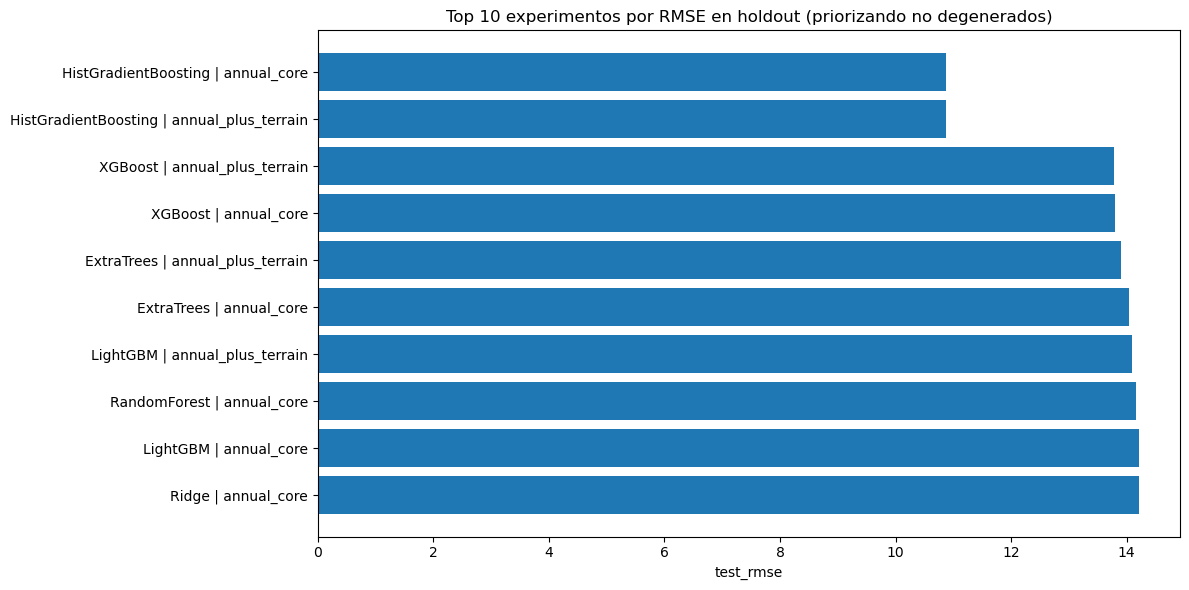

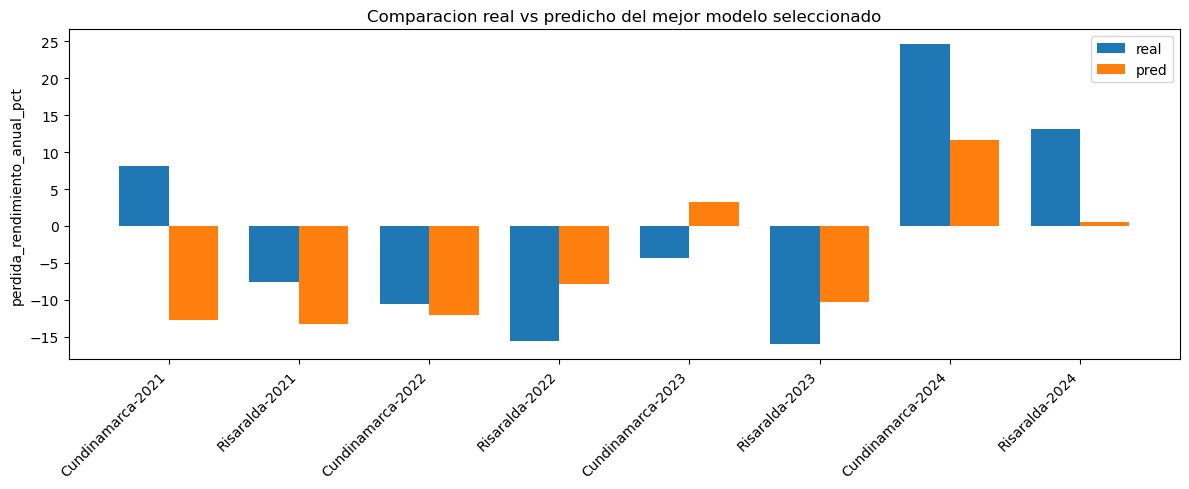

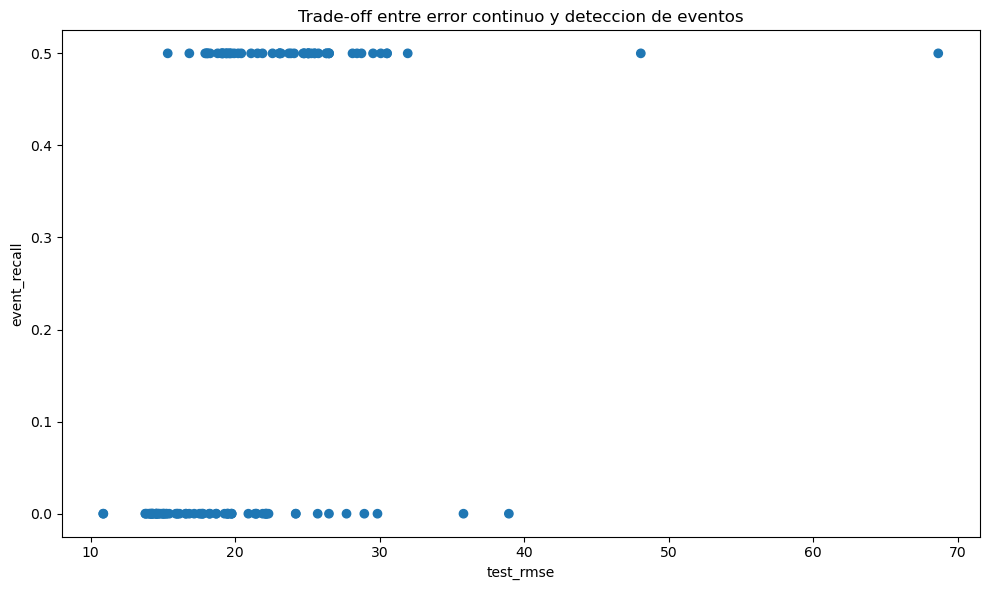

In [37]:
if MATPLOTLIB_AVAILABLE and len(test_results_df) > 0:
    plot_df = (non_degenerate_results_df if len(non_degenerate_results_df) > 0 else test_results_df).head(10).copy()
    labels = plot_df['model_name'] + ' | ' + plot_df['feature_set']
    plt.figure(figsize=(12, 6))
    plt.barh(labels, plot_df['test_rmse'])
    plt.gca().invert_yaxis()
    plt.xlabel('test_rmse')
    plt.title('Top 10 experimentos por RMSE en holdout (priorizando no degenerados)')
    plt.tight_layout()
    plt.show()

if MATPLOTLIB_AVAILABLE and len(top_predictions) > 0:
    best_row = top_models_summary.iloc[0]
    best_preds = top_predictions.loc[
        (top_predictions['model_name'] == best_row['model_name']) &
        (top_predictions['feature_set'] == best_row['feature_set'])
    ].copy()
    best_preds['label'] = best_preds['departamento'] + '-' + best_preds['anio'].astype(str)
    x = np.arange(len(best_preds))
    width = 0.38
    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, best_preds['y_real'], width=width, label='real')
    plt.bar(x + width / 2, best_preds['y_pred'], width=width, label='pred')
    plt.xticks(x, best_preds['label'], rotation=45, ha='right')
    plt.ylabel('perdida_rendimiento_anual_pct')
    plt.title('Comparacion real vs predicho del mejor modelo seleccionado')
    plt.legend()
    plt.tight_layout()
    plt.show()

if MATPLOTLIB_AVAILABLE and len(test_results_df) > 0:
    scatter_df = test_results_df.copy()
    colors = scatter_df['degenerate_prediction_flag'].map({True: 'tab:red', False: 'tab:blue'})
    plt.figure(figsize=(10, 6))
    plt.scatter(scatter_df['test_rmse'], scatter_df['event_recall'], c=colors)
    plt.xlabel('test_rmse')
    plt.ylabel('event_recall')
    plt.title('Trade-off entre error continuo y deteccion de eventos')
    plt.tight_layout()
    plt.show()


## Exportacion de resultados y log de corrida

Se guardan archivos auxiliares para facilitar auditoria, comparacion posterior y revision del experimento fuera del notebook.


In [38]:
export_status = []

try:
    dependency_report.to_csv(OUTPUT_DIR / 'dependencias_detectadas.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'dependencias_detectadas.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'dependencias_detectadas.csv', 'estado': f'fallo: {exc}'})

try:
    feature_sets_table.to_csv(OUTPUT_DIR / 'feature_sets_utilizados.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'feature_sets_utilizados.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'feature_sets_utilizados.csv', 'estado': f'fallo: {exc}'})

if len(cv_results_df) > 0:
    try:
        cv_results_df.to_csv(OUTPUT_DIR / 'resumen_cv_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_cv_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_cv_modelos.csv', 'estado': f'fallo: {exc}'})

if len(test_results_df) > 0:
    try:
        test_results_df.to_csv(OUTPUT_DIR / 'resumen_test_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_test_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_test_modelos.csv', 'estado': f'fallo: {exc}'})

if len(non_degenerate_results_df) > 0:
    try:
        non_degenerate_results_df.to_csv(OUTPUT_DIR / 'resumen_test_modelos_no_degenerados.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_test_modelos_no_degenerados.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_test_modelos_no_degenerados.csv', 'estado': f'fallo: {exc}'})

if len(event_top_models) > 0:
    try:
        event_top_models.to_csv(OUTPUT_DIR / 'resumen_test_modelos_priorizando_eventos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_test_modelos_priorizando_eventos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_test_modelos_priorizando_eventos.csv', 'estado': f'fallo: {exc}'})

if len(predictions_df) > 0:
    try:
        predictions_df.to_csv(OUTPUT_DIR / 'predicciones_holdout_todos_los_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'predicciones_holdout_todos_los_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'predicciones_holdout_todos_los_modelos.csv', 'estado': f'fallo: {exc}'})

if len(top_predictions) > 0:
    try:
        top_predictions.to_csv(OUTPUT_DIR / 'predicciones_top_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'predicciones_top_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'predicciones_top_modelos.csv', 'estado': f'fallo: {exc}'})

if len(top_models_summary) > 0:
    try:
        top_models_summary.to_csv(OUTPUT_DIR / 'top_modelos_seleccionados.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'top_modelos_seleccionados.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'top_modelos_seleccionados.csv', 'estado': f'fallo: {exc}'})

config_payload = {
    'target': TARGET,
    'event_threshold': EVENT_THRESHOLD,
    'train_end_year': TRAIN_END_YEAR,
    'small_train_end_year': SMALL_TRAIN_END_YEAR,
    'small_valid_end_year': SMALL_VALID_END_YEAR,
    'cv_min_train_years': CV_MIN_TRAIN_YEARS,
    'cv_valid_window': CV_VALID_WINDOW,
    'degenerate_std_threshold': DEGENERATE_STD_THRESHOLD,
    'degenerate_range_threshold': DEGENERATE_RANGE_THRESHOLD,
    'feature_sets': feature_sets,
    'dependency_status': dependency_status_text(dependency_report)
}
try:
    safe_write_text(OUTPUT_DIR / 'config_experimento.json', json.dumps(config_payload, ensure_ascii=False, indent=2))
    export_status.append({'archivo': 'config_experimento.json', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'config_experimento.json', 'estado': f'fallo: {exc}'})

safe_write_text(OUTPUT_DIR / 'baseline_regresion_run_log.txt', '\n'.join(run_log))
export_status.append({'archivo': 'baseline_regresion_run_log.txt', 'estado': 'ok o intento de escritura realizado'})


if len(adjustments_log) > 0:
    try:
        adjustments_log.to_csv(OUTPUT_DIR / 'ajustes_modelado_regresion.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'ajustes_modelado_regresion.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'ajustes_modelado_regresion.csv', 'estado': f'fallo: {exc}'})

if len(candidate_models) > 0:
    try:
        candidate_models.to_csv(OUTPUT_DIR / 'candidatos_modelos_por_objetivo.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'candidatos_modelos_por_objetivo.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'candidatos_modelos_por_objetivo.csv', 'estado': f'fallo: {exc}'})

if len(candidate_summary) > 0:
    try:
        candidate_summary.to_csv(OUTPUT_DIR / 'resumen_candidatos_recomendados.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_candidatos_recomendados.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_candidatos_recomendados.csv', 'estado': f'fallo: {exc}'})

if len(limitations_and_next_steps) > 0:
    try:
        limitations_and_next_steps.to_csv(OUTPUT_DIR / 'limitaciones_y_siguientes_refinamientos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'limitaciones_y_siguientes_refinamientos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'limitaciones_y_siguientes_refinamientos.csv', 'estado': f'fallo: {exc}'})

export_status_df = pd.DataFrame(export_status)
display(export_status_df)



,archivo,estado
0,dependencias_detectadas.csv,ok
1,feature_sets_utilizados.csv,ok
2,resumen_cv_modelos.csv,ok
3,resumen_test_modelos.csv,ok
4,resumen_test_modelos_no_degenerados.csv,ok
5,resumen_test_modelos_priorizando_eventos.csv,ok
6,predicciones_holdout_todos_los_modelos.csv,ok
7,predicciones_top_modelos.csv,ok
8,top_modelos_seleccionados.csv,ok
9,config_experimento.json,ok


## Lectura final del bloque de regresion

El valor de este notebook no esta solo en encontrar un ganador, sino en dejar trazable el espacio inicial de modelos, tecnicas y comparaciones que vale la pena seguir refinando.


In [39]:
final_summary = []

if len(test_results_df) > 0:
    best_primary = (non_degenerate_results_df if len(non_degenerate_results_df) > 0 else test_results_df).iloc[0]
    best_event = event_top_models.iloc[0] if len(event_top_models) > 0 else best_primary
    final_summary.extend([
        {'tema': 'mejor_modelo_seleccion_general', 'lectura': f"{best_primary['model_name']} con feature_set {best_primary['feature_set']}"},
        {'tema': 'mejor_rmse_holdout', 'lectura': f"{best_primary['test_rmse']:.4f}"},
        {'tema': 'mejor_r2_holdout', 'lectura': f"{best_primary['test_r2']:.4f}"},
        {'tema': 'prediccion_degenerada_mejor_modelo', 'lectura': str(bool(best_primary['degenerate_prediction_flag']))},
        {'tema': 'mejor_modelo_eventos', 'lectura': f"{best_event['model_name']} con feature_set {best_event['feature_set']}"},
        {'tema': 'recall_eventos_mejor_modelo_eventos', 'lectura': f"{best_event['event_recall']:.4f}"},
        {'tema': 'f1_eventos_mejor_modelo_eventos', 'lectura': f"{best_event['event_f1']:.4f}"},
        {'tema': 'feature_set_mas_prometedor', 'lectura': str(source_general.iloc[0]['feature_set'])},
        {'tema': 'necesidad_de_clasificacion_formal', 'lectura': 'si, para profundizar la deteccion de eventos en notebook 11'}

    ])
else:
    final_summary.append({'tema': 'estado', 'lectura': 'No se ejecutaron modelos en este entorno porque faltan dependencias de modelado.'})

display(pd.DataFrame(final_summary))
print('Notebook 10 listo.')


,tema,lectura
0,mejor_modelo_seleccion_general,HistGradientBoosting con feature_set annual_core
1,mejor_rmse_holdout,10.8745
2,mejor_r2_holdout,0.3794
3,prediccion_degenerada_mejor_modelo,False
4,mejor_modelo_eventos,LightGBM con feature_set corr_diversified_train
5,recall_eventos_mejor_modelo_eventos,0.5000
6,f1_eventos_mejor_modelo_eventos,0.6667
7,feature_set_mas_prometedor,annual_core
8,necesidad_de_clasificacion_formal,"si, para profundizar la deteccion de eventos en notebook 11"


Notebook 10 listo.
